# Gala projekts: Divpakāpju PageValues prognozēšana

Week4 parādīja, ka tieša PageValues regresija nedarbojas — R² = 0.046, jo 78% datu PageValues = 0.

Risinājums: sadalīt uzdevumu divās pakāpēs.
1. Klasifikācija — vai PageValues > 0?
2. Regresija — prognozēt vērtību tikai pozitīvajām rindām.

## Datu ielāde

Ielādējam oriģinālo datu kopu no UCI, nevis week2/shoppers_clean.csv. Week2 normalizēja arī PageValues - tas ir kļūda, jo target mainīgais nav jānormalizē. Features normalizēsim iekš Pipeline.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (f1_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, mean_squared_error, r2_score)

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv'
df = pd.read_csv(url)

print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print(f"\nKolonnas:\n{df.columns.tolist()}")
print(f"\nDatu tipi:\n{df.dtypes}")

ValueError: Error reading file: Error tokenizing data. C error: Expected 1 fields in line 4, saw 3


In [ ]:
# Preprocessing — tāpat kā week2
# Kategoriskās kolonnas: Month, VisitorType -> OHE
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=False)

# Boolean kolonnas -> int
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

print(f"Pēc preprocessing: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print(f"\nPageValues statistika:")
print(df['PageValues'].describe().round(3))

NameError: name 'pd' is not defined

## Izpēte: PageValues sadalījums un 78% nullu problēma

PageValues = 0:     9600 rindas (77.9%)
PageValues > 0:     2730 rindas (22.1%)

Sagaidāmā problēma ar tiešu regresiju (week4 rezultāts):
  Lineārā regresija R² = 0.046
  Random Forest R²     = 0.070


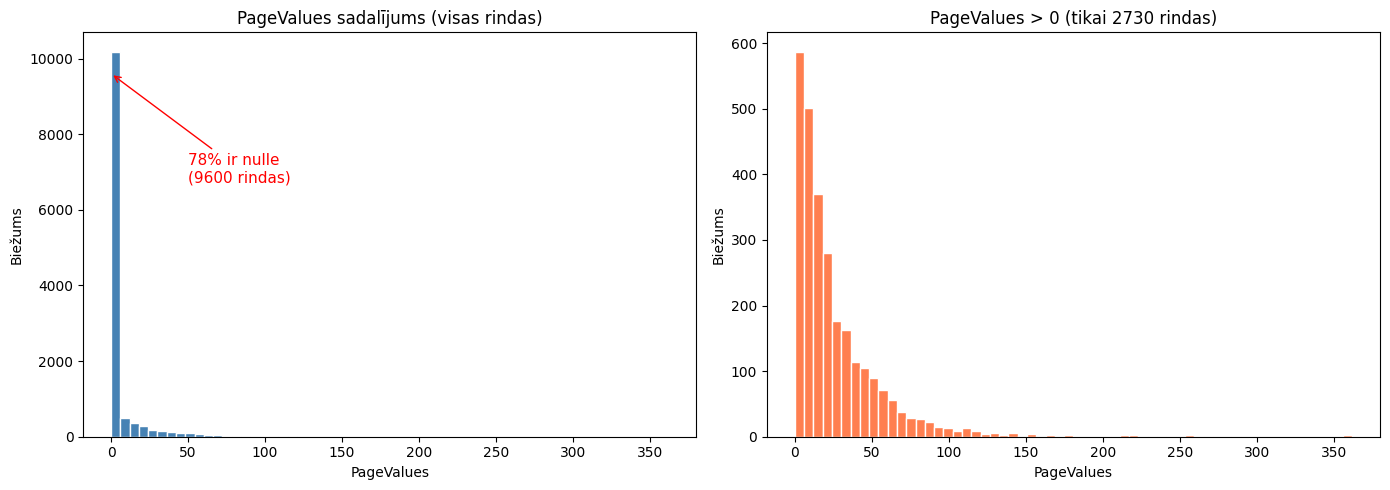

In [ ]:
zero_count = (df['PageValues'] == 0).sum()
nonzero_count = (df['PageValues'] > 0).sum()
zero_pct = zero_count / len(df) * 100

print(f"PageValues = 0:    {zero_count:5d} rindas ({zero_pct:.1f}%)")
print(f"PageValues > 0:    {nonzero_count:5d} rindas ({100-zero_pct:.1f}%)")
print(f"\nSagaidāmā problēma ar tiešu regresiju (week4 rezultāts):")
print(f"  Lineārā regresija R² = 0.046")
print(f"  Random Forest R²     = 0.070")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Viss sadalījums (ar nullēm)
axes[0].hist(df['PageValues'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('PageValues sadalījums (visas rindas)')
axes[0].set_xlabel('PageValues')
axes[0].set_ylabel('Biežums')
axes[0].annotate(f'78% ir nulle\n({zero_count} rindas)', xy=(0, zero_count),
                 xytext=(50, zero_count * 0.7),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=11)

# Tikai nenulles
axes[1].hist(df[df['PageValues'] > 0]['PageValues'], bins=60,
             color='coral', edgecolor='white')
axes[1].set_title(f'PageValues > 0 (tikai {nonzero_count} rindas)')
axes[1].set_xlabel('PageValues')
axes[1].set_ylabel('Biežums')

plt.tight_layout()
plt.show()

## 1. solis: Klasifikācija

Prognozēt, vai klientam PageValues > 0. Target: binārs (0 vai 1), ~22% pozitīvo.

Features: visas kolonnas izņemot PageValues un Revenue. Revenue izņemam — tā ir nākotnes informācija (data leakage).

Modelis: Pipeline(StandardScaler + RandomForestClassifier) ar GridSearchCV.

In [ ]:
# Sagatavo klasifikācijas datus
y_clf = (df['PageValues'] > 0).astype(int)
X_clf = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Klases sadalījums:")
print(f"  PageValues = 0  (klase 0): {(y_clf == 0).sum()} ({(y_clf == 0).mean():.1%})")
print(f"  PageValues > 0  (klase 1): {(y_clf == 1).sum()} ({(y_clf == 1).mean():.1%})")
print(f"\nFeatures skaits: {X_clf.shape[1]}")

# Sadalījums ar stratify — saglabā klases proporcijas abās kopās
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f"\nTreniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa:   {X_test.shape[0]} rindas")

Klases sadalījums:
  PageValues = 0  (klase 0): 9600 (77.9%)
  PageValues > 0  (klase 1): 2730 (22.1%)

Features skaits: 27

Treniņa kopa: 9864 rindas
Testa kopa:   2466 rindas


In [ ]:
# Pipeline: StandardScaler + RandomForestClassifier
# Pipeline nodrošina, ka scaler tiek fit tikai uz train datiem katrā CV fold
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# GridSearchCV — automātiska hiperparametru meklēšana
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"\nLabākie parametri:  {grid.best_params_}")
print(f"Labākais CV F1:     {grid.best_score_:.3f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits



Labākie parametri:  {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 100}
Labākais CV F1:     0.451


In [ ]:
# Novērtējums uz testa kopas ar labāko modeli
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

test_f1  = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)

print("=== Klasifikācijas rezultāti (testa kopa) ===")
print(f"F1 score:  {test_f1:.3f}")
print(f"AUC-ROC:   {test_auc:.3f}")
print(f"\nDetalizēts pārskats:")
print(classification_report(y_test, y_pred,
                             target_names=['PageValues=0', 'PageValues>0']))

=== Klasifikācijas rezultāti (testa kopa) ===
F1 score:  0.453
AUC-ROC:   0.848

Detalizēts pārskats:
              precision    recall  f1-score   support

PageValues=0       0.84      0.95      0.89      1920
PageValues>0       0.67      0.34      0.45       546

    accuracy                           0.82      2466
   macro avg       0.75      0.65      0.67      2466
weighted avg       0.80      0.82      0.79      2466



### Vizualizācijas: Confusion Matrix, ROC Curve, GridSearch heatmap

C:\Users\Ilya\Documents\fita-ml-course\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


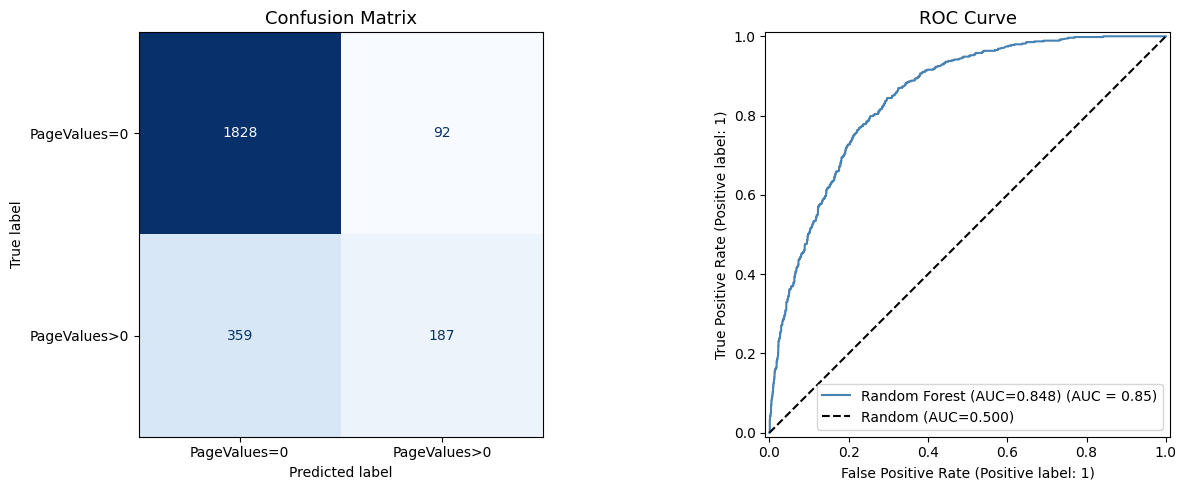

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['PageValues=0', 'PageValues>0'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                  name=f'Random Forest (AUC={test_auc:.3f})',
                                  color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

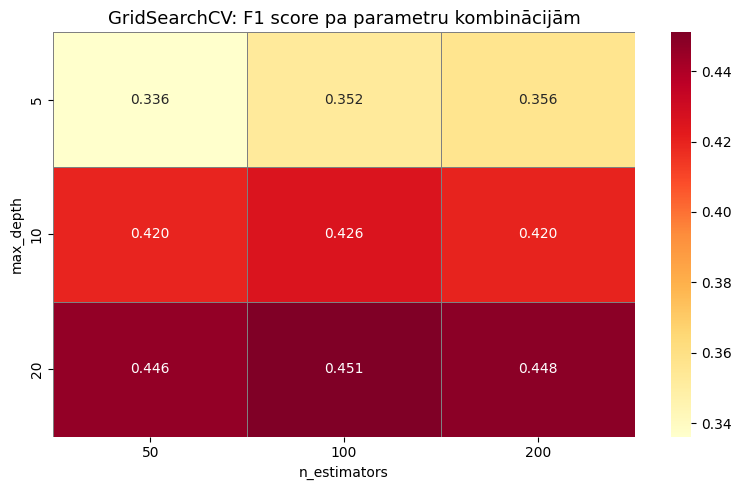

Labākā kombinācija: max_depth=20, n_estimators=100


In [ ]:
# GridSearchCV heatmap — F1 score pa parametru kombinācijām
results_df = pd.DataFrame(grid.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='gray')
plt.title('GridSearchCV: F1 score pa parametru kombinācijām', fontsize=13)
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

# Atzīmē labāko kombināciju
best_depth = grid.best_params_['randomforestclassifier__max_depth']
best_est   = grid.best_params_['randomforestclassifier__n_estimators']
print(f"Labākā kombinācija: max_depth={best_depth}, n_estimators={best_est}")

### Klasifikācijas secinājumi

Heatmap rāda, ka lielāks max_depth uzlabo F1, bet atšķirība starp depth=10 un depth=20 ir neliela (~0.01–0.02). n_estimators ietekme ir vēl mazāka — pietiek ar 100 kokiem.

F1 ir galvenā metrika nebalansētām klasēm. AUC-ROC mēra modeli neatkarīgi no sliekšņa — vērtība 0.848 nozīmē, ka modelis labi ranžē klientus pēc pirkumu varbūtības.

## 2. solis: Regresija

Filtrējam tikai rindas ar PageValues > 0 (~2730 rindas) un prognozējam faktisko vērtību. Nav 78% nullu problēmas.

Modelis: Pipeline(StandardScaler + RandomForestRegressor) ar 5-fold cross-validation.

In [ ]:
# Filtrēšana — tikai rindas ar PageValues > 0
df_nonzero = df[df['PageValues'] > 0].copy()
y_reg = df_nonzero['PageValues']
X_reg = df_nonzero.drop(['PageValues', 'Revenue'], axis=1)

print(f"Regresijas datu kopa: {len(df_nonzero)} rindas")
print(f"PageValues statistika (tikai nenulles):")
print(y_reg.describe().round(2))

# Pipeline: StandardScaler + RandomForestRegressor
pipe_reg = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(n_estimators=100, random_state=42)
)

# 5-fold cross-validation
cv_rmse = cross_val_score(pipe_reg, X_reg, y_reg, cv=5,
                           scoring='neg_root_mean_squared_error')
cv_r2   = cross_val_score(pipe_reg, X_reg, y_reg, cv=5, scoring='r2')

print(f"\n=== Regresijas rezultāti (5-fold CV) ===")
print(f"RMSE: {(-cv_rmse).mean():.3f} ± {cv_rmse.std():.3f}")
print(f"R²:   {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"\nSalīdzinājums ar week4:")
print(f"  Week4 R² (visas rindas, ar nullēm): 0.046 - 0.070")
print(f"  Week5 R² (tikai PageValues > 0):    {cv_r2.mean():.3f}")

Regresijas datu kopa: 2730 rindas
PageValues statistika (tikai nenulles):
count    2730.00
mean       26.60
std        31.73
min         0.04
25%         7.21
50%        16.66
75%        34.78
max       361.76
Name: PageValues, dtype: float64



=== Regresijas rezultāti (5-fold CV) ===
RMSE: 30.194 ± 4.225
R²:   0.078 ± 0.146

Salīdzinājums ar week4:
  Week4 R² (visas rindas, ar nullēm): 0.046 - 0.070
  Week5 R² (tikai PageValues > 0):    0.078


### Vizualizācijas: faktiskās vs prognozētās, feature importance top 10

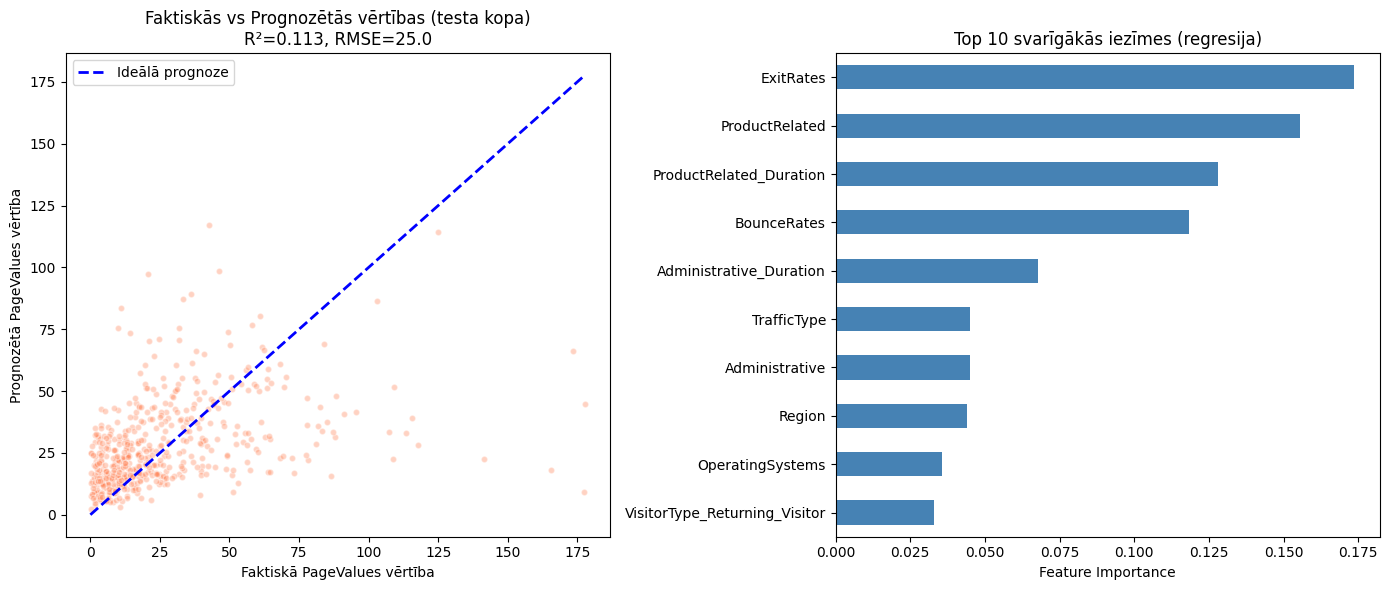


Testa kopa R²:   0.113
5-fold CV R²:    0.078 ± 0.146


In [ ]:
# Treniņa/testa sadalījums regresijas vizualizācijai
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
pipe_reg.fit(X_reg_train, y_reg_train)
y_reg_pred = pipe_reg.predict(X_reg_test)

test_r2   = r2_score(y_reg_test, y_reg_pred)
test_rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Scatter: faktiskās vs prognozētās (testa kopa) ---
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.35, color='coral',
                edgecolors='white', s=20)
max_val = max(y_reg_test.max(), y_reg_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'b--', linewidth=2, label='Ideālā prognoze')
axes[0].set_xlabel('Faktiskā PageValues vērtība')
axes[0].set_ylabel('Prognozētā PageValues vērtība')
axes[0].set_title(f'Faktiskās vs Prognozētās vērtības (testa kopa)\n'
                  f'R²={test_r2:.3f}, RMSE={test_rmse:.1f}')
axes[0].legend()

# --- Feature importance top 10 ---
rf_model = pipe_reg.named_steps['randomforestregressor']
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=X_reg.columns).sort_values(ascending=True).tail(10)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 svarīgākās iezīmes (regresija)')
axes[1].set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

print(f"\nTesta kopa R²:   {test_r2:.3f}")
print(f"5-fold CV R²:    {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

## Secinājumi

**Klasifikācija:** F1 = 0.453, AUC-ROC = 0.848. Modelis labi ranžē klientus — AUC 0.848 ir ievērojami labāks par nejaušu minēšanu. Zemais recall (0.34) skaidrojams ar klases nelīdzsvarotību: modelis ir piesardzīgs un neprognozē klasi 1, ja nav pārliecināts.

**Regresija:** CV R² = 0.078 salīdzinot ar week4 R² = 0.046–0.070. Uzlabojums ir mērens, jo PageValues sadalījums joprojām ir right-skewed pat pēc nullu filtrēšanas (mediāna=17, max=362). Divpakāpju pieeja metodiski ir pareizāka — mēs izolējam prognozēšanas uzdevumu no masveida nullēm.

**Biznesa lietojums:** Klasifikācijas modelis reāllaikā identificē klientus ar pirkuma nolūku. Klientiem ar augstu varbūtību var rādīt mērķtiecīgus piedāvājumus. AUC-ROC ļauj pielāgot slieksni atbilstoši biznesa vajadzībām (augstāks recall = vairāk piedāvājumu, augstāka precizitāte = mazāk, bet precīzāk).

**Ko varētu uzlabot:** class_weight='balanced' uzlabotu recall klasifikācijā. Log-transformācija uz PageValues (log1p) normalizētu right-skewed sadalījumu un uzlabotu regresijas R².